In [1]:
from qiskit.quantum_info import random_statevector

state = random_statevector(8)
state.inner(state)

np.complex128(1.0000000000000002+0j)

In [2]:
import os
import gc
gc.collect()

# --- Imports que ya usabas ---
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix, negativity, state_fidelity, Operator, concurrence, entropy


import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import sympy as sym


def three_t(yf):
    # yf es vector amplitudes complejas (8 componentes)
    # Asegurarse vector numpy 1D
    yf = np.asarray(yf).flatten()
    if yf.size != 8:
        raise ValueError("three_t espera vector de 8 amplitudes")
    m1 = (yf[0] * yf[7])**2 + (yf[1] * yf[6])**2 + (yf[2] * yf[5])**2 + (yf[3] * yf[4])**2
    m2 = (yf[0] * yf[7] * yf[3] * yf[4] + yf[0] * yf[7] * yf[5] * yf[2] +
          yf[0] * yf[7] * yf[6] * yf[1] + yf[3] * yf[4] * yf[5] * yf[2] +
          yf[3] * yf[4] * yf[6] * yf[1] + yf[5] * yf[2] * yf[6] * yf[1])
    m3 = yf[0] * yf[6] * yf[5] * yf[3] + yf[7] * yf[1] * yf[2] * yf[4]
    tau =  4 * abs(m1 - 2 * m2 + 4 * m3)
    return tau



def random_GHZ_pulse(yf):
        # función objetivo que mide igualdad entre concurrencias
        conc_01 = concurrence(partial_trace(yf, [2]))
        conc_02 = concurrence(partial_trace(yf, [1]))
        conc_12 = concurrence(partial_trace(yf, [0]))
        cost = np.sqrt((conc_01 - 2/3)**2 + (conc_12 - 2/3)**2 + (conc_02 - 2/3)**2)
        
        return cost


In [3]:
W = Statevector([0,1/np.sqrt(3),1/np.sqrt(3),0,1/np.sqrt(3),0,0,0])
W.draw('latex')
random_GHZ_pulse(W)

np.float64(1.9229626863835638e-16)

In [4]:
GHZ = Statevector([1/np.sqrt(2),0,0,0,0,0,0,1/np.sqrt(2)])
GHZ.draw('latex')
random_GHZ_pulse(GHZ)

np.float64(1.1547005383792515)

In [5]:
three_t(GHZ)

np.float64(0.9999999999999996)

In [13]:
ran_GHZ = []
ran_W   = []
for i in range(3000000):
    state = random_statevector(8)
    if random_GHZ_pulse(state) > 1:
        ran_GHZ.append(random_GHZ_pulse(state))
        ran_W.append(three_t(state))


In [5]:
min(ran_W)

NameError: name 'ran_W' is not defined

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_13728\1146559281.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')


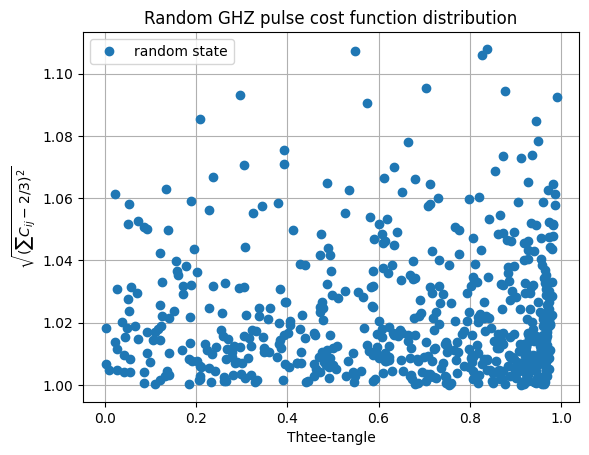

In [ ]:
plt.plot(ran_W,ran_GHZ,'o',label='random state')
plt.xlabel('Thtee-tangle')
plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')
plt.title('Random GHZ pulse cost function distribution')
plt.grid()
plt.legend()
plt.show()


In [31]:
import numpy as np

# Dimension N
N = 8

# 1. Generate a random complex vector using normal distribution for real and imaginary parts
# A normal distribution is used to sample from the Hilbert space according to the Ginibre ensemble
random_vector = np.random.normal(size=N) + 1j * np.random.normal(size=N)

# 2. Normalize the vector to a unit norm (L2 norm)
# The L2 norm is the square root of the sum of the squares of all the components' magnitudes
norm = np.linalg.norm(random_vector)
normalized_state_vector = random_vector / norm

print("Random Quantum State Vector:")
print(normalized_state_vector)
print("\nNorm check (should be close to 1):")
print(np.linalg.norm(normalized_state_vector))



Random Quantum State Vector:
[-0.31782669-0.08436649j  0.22503038-0.19876078j -0.26488042-0.00557484j
  0.1522356 +0.48307121j  0.02423377+0.26857774j -0.41117264+0.41906781j
  0.20743618-0.10900354j -0.01148629-0.05051987j]

Norm check (should be close to 1):
1.0


In [36]:
import numpy as np

N = 8  # dimensión del vector

for i in range(10):
    random_vector = np.random.normal(size=N) + 1j * np.random.normal(size=N)
    norm = np.linalg.norm(random_vector)
    normalized_state_vector = random_vector / norm
    print(normalized_state_vector)

[ 0.03396816+0.35600496j -0.4918086 -0.18846993j -0.06054925+0.16678742j
 -0.18887784-0.42010909j  0.14220262+0.08050812j  0.16559407-0.0332235j
 -0.17354413+0.46284798j -0.20742469+0.09197894j]
[-0.18463462+0.31054315j -0.30320746+0.27548434j -0.38156633-0.07754398j
 -0.05988981+0.27809385j -0.08246297-0.39815522j -0.39189515-0.2595342j
 -0.24398422+0.10685439j -0.10688333-0.0219084j ]
[ 0.24123838-0.16918935j -0.36257946-0.50730476j -0.05606661-0.15276397j
 -0.06975585-0.12827268j -0.02459753-0.30677875j -0.04025253+0.18434615j
 -0.11519481+0.45817671j  0.08125277-0.34122896j]
[-0.05762515-0.17113673j -0.02390248-0.35626074j  0.2873171 -0.08493918j
 -0.40788964-0.51101442j -0.24199637-0.01042914j -0.02130417+0.25148097j
  0.29327696+0.08361818j -0.04935016+0.32375404j]
[-0.00176651+0.03435099j -0.14827664+0.08637836j  0.52948341-0.05065543j
 -0.623695  -0.28874924j  0.1358983 +0.30858144j  0.15604385+0.07391977j
  0.05059147-0.19958485j -0.16709771-0.01611049j]
[-0.21370514+0.6333613

In [3]:
import numpy as np
datos = np.loadtxt("datos_tabulados.txt", delimiter=',')

C:\Users\PC\AppData\Local\Temp\ipykernel_21260\325088808.py:2: UserWarning: loadtxt: input contained no data: "datos_tabulados.txt"
  datos = np.loadtxt("datos_tabulados.txt", delimiter=',')


In [4]:
x = datos[:,0]
y = datos[:,1]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
import matplotlib.pyplot as plt
plt.plot(x,y,'o',label='random state')
plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')
plt.xlabel('Thtee-tangle')  

In [6]:
datos_pulso_GHZ_tangle = np.loadtxt("datos_pulso_GHZ_tangle.txt", delimiter=',')
datos_pulso_GHZ_w = np.loadtxt("datos_pulso_GHZ_w.txt", delimiter=',')

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_21260\1950910241.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')


(-0.05, 1.2)

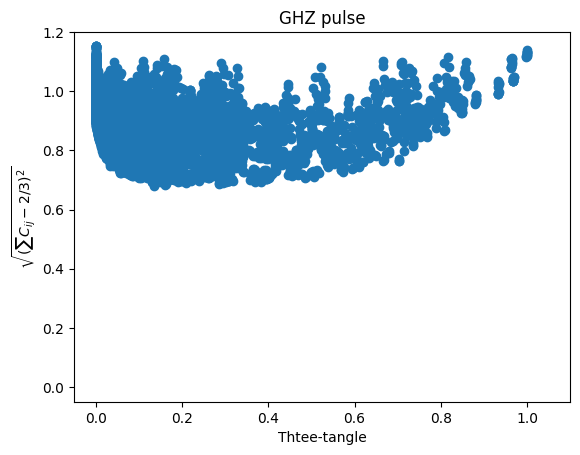

In [7]:
import matplotlib.pyplot as plt
plt.title('GHZ pulse')
plt.plot(datos_pulso_GHZ_tangle,datos_pulso_GHZ_w,'o',label='random state')
plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')
plt.xlabel('Thtee-tangle')  
plt.xlim(-0.05,1.1)
plt.ylim(-0.05,1.2)

In [8]:
state_random_tangle = np.loadtxt("state_random_tangle_200mil.txt", delimiter=',')
state_random_W_200mil = np.loadtxt("state_random_W_200mil.txt", delimiter=',')

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_21260\3128723560.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')


(-0.05, 1.2)

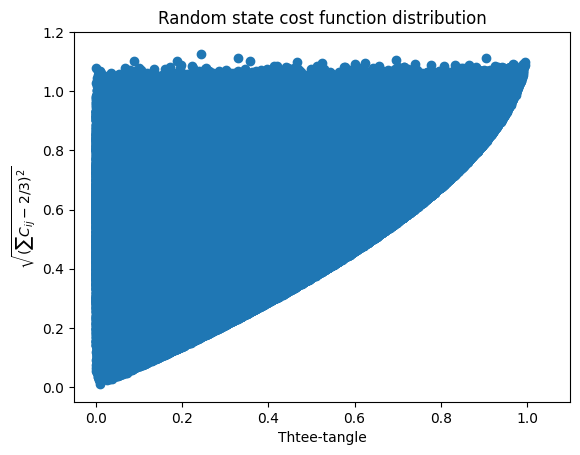

In [9]:
import matplotlib.pyplot as plt
plt.title('Random state cost function distribution')
plt.plot(state_random_W_200mil  ,state_random_tangle,'o',label='random state')
plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')
plt.xlabel('Thtee-tangle')  
plt.xlim(-0.05,1.1)
plt.ylim(-0.05,1.2)

In [10]:
datos_pulso_w_tangle = np.loadtxt("datos_pulso_w_tangle.txt", delimiter=',')
datos_pulso__w = np.loadtxt("datos_pulso_w.txt", delimiter=',')

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_21260\1915642400.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')


(-0.05, 1.2)

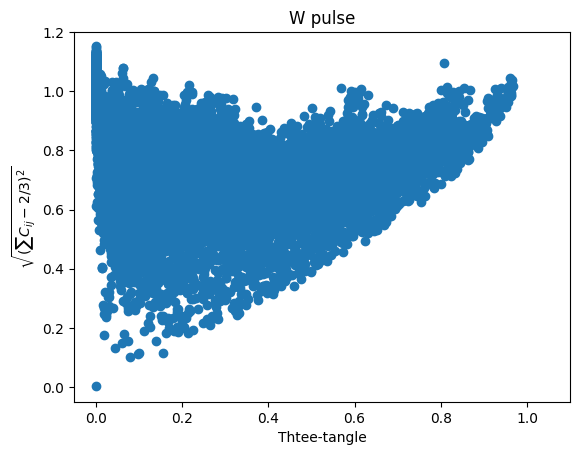

In [16]:
import matplotlib.pyplot as plt
plt.title('W pulse')
plt.plot(datos_pulso_w_tangle,datos_pulso__w,'o',label='random state')
plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')
plt.xlabel('Thtee-tangle')  
plt.xlim(-0.05,1.1)
plt.ylim(-0.05,1.2)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_21260\3490276075.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')


AttributeError: 'function' object has no attribute 'scatter'

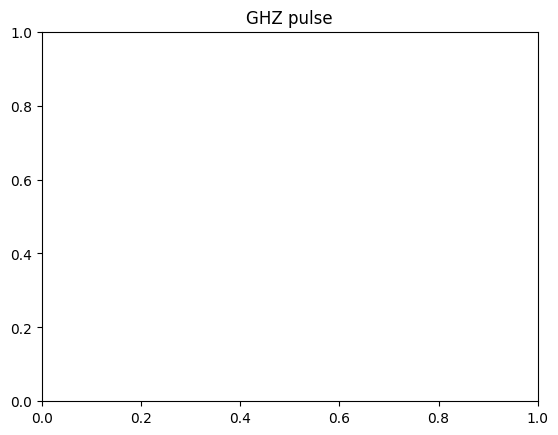

In [17]:
import matplotlib.pyplot as plt

plt.title('GHZ pulse')
plt.plot.scatter(datos_pulso_GHZ_tangle,datos_pulso_GHZ_w,'o',label=' GHZ like pulse', color='#2C6BAA',alpha=0.5)
plt.plot.scatter(datos_pulso_w_tangle,datos_pulso__w,'x',label=' W like pulse ', color='#9BBF8A', alpha=0.45)
plt.ylabel('$\sqrt{(\sum C_{ij} - 2/3 )^{2}} $')
plt.xlabel('Thtee-tangle')  
plt.legend()
plt.xlim(-0.05,1.1)
plt.ylim(-0.05,1.2)

C:\Users\PC\AppData\Local\Temp\ipykernel_21260\2511625478.py:17: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


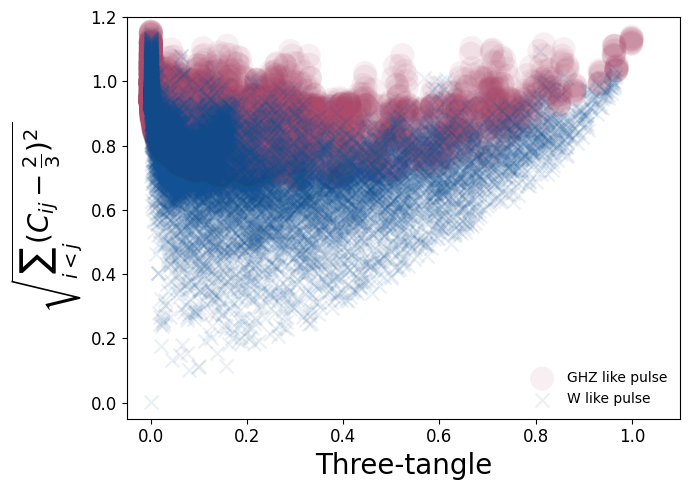

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
# plt.title('GHZ pulse')

plt.scatter(
    datos_pulso_GHZ_tangle,
    datos_pulso_GHZ_w,
    marker='o',
    s=300,
    color="#AB4A6B",
    alpha=0.088,        # ⬅ más bajo = más sombreado en intersecciones
    edgecolors='none',
    label='GHZ like pulse'
)

plt.scatter(
    datos_pulso_w_tangle,
    datos_pulso__w,
    marker='x',        # usa 'o' mejor que 'x' con alpha
   s=100,
    color="#125194",
    alpha=0.088,
    edgecolors='none',
    label='W like pulse'
)

plt.ylabel(r'$\sqrt{\sum_{i<j}( C_{ij} - \frac{2}{3} )^{2}}$', fontsize=20)
plt.xlabel('Three-tangle', fontsize=20)

plt.xticks(rotation=0,fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-0.05, 1.1)
plt.ylim(-0.05, 1.2)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


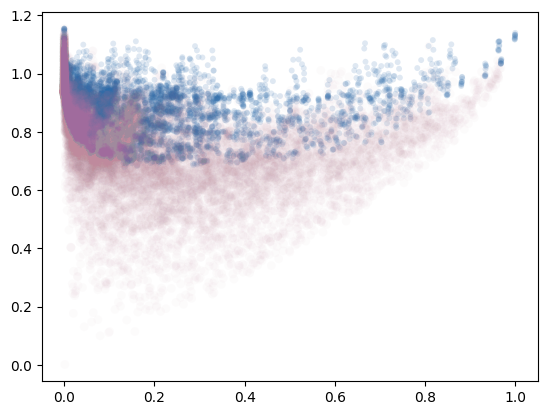

In [94]:
plt.scatter(
    datos_pulso_GHZ_tangle,
    datos_pulso_GHZ_w,
    s=18,
    color='#2C6BAA',
    alpha=0.15,        # ⬅ más bajo = más sombreado en intersecciones
    edgecolors='none',
    label='GHZ like pulse'
)

plt.scatter(
    datos_pulso_w_tangle,
    datos_pulso__w,
    s=40,
    color="#BF8A9D",
    alpha=0.03,
    edgecolors='none',
    label='W like pulse'
)


In [1]:
# Quantum system
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, Operator, DensityMatrix, state_fidelity, concurrence, entropy, negativity
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

from qiskit_dynamics import Solver, Signal
import numpy as np
from scipy.optimize import rosen, differential_evolution

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize
import random
import sympy as sym 
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

# Llamar fake backend
backend = FakeSherbrooke()

# Configuración de backend
propiedades = backend.properties()
configuracion = backend.configuration()

Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7 = configuracion.hamiltonian.get("vars").get("wq7")
w8 = configuracion.hamiltonian.get("vars").get("wq8")
w9 = configuracion.hamiltonian.get("vars").get("wq9")
# anharmonicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0 = configuracion.hamiltonian.get("vars").get("omegad7")
r1 = configuracion.hamiltonian.get("vars").get("omegad8")
r2 = configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt * 1e9

v7 = w7 / (2 * np.pi)
v8 = w8 / (2 * np.pi)
v9 = w9 / (2 * np.pi)
print(v7, v8, v9)

# ========== Operadores ==========
# Definir los operadores 
dim = 3
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 = np.kron(ident, np.kron(ident, N))
N1 = np.kron(ident, np.kron(N, ident))
N2 = np.kron(np.kron(N, ident), ident)

a0 = np.kron(ident, np.kron(ident, a))
a1 = np.kron(ident, np.kron(a, ident))
a2 = np.kron(np.kron(a, ident), ident)

a0dag = np.kron(ident, np.kron(ident, adag))
a1dag = np.kron(ident, np.kron(adag, ident))
a2dag = np.kron(np.kron(adag, ident), ident)

# Hamiltoniano del sistema
static_ham = (2 * np.pi * v7 * N0 + delta7 * (a0dag @ a0dag @ a0 @ a0) / 2 + 
              2 * np.pi * v8 * N1 + delta8 * (a1dag @ a1dag @ a1 @ a1) / 2 + 
              2 * np.pi * v9 * N2 + delta9 * (a2dag @ a2dag @ a2 @ a2) / 2 + 
              J78 * (a0dag @ a1 + a0 @ a1dag) + J89 * (a1dag @ a2 + a1 @ a2dag))

# Hamiltonianos de controles
H_drive7 = r0 * (a0 + a0dag)
H_drive8 = r1 * (a1 + a1dag)
H_drive9 = r2 * (a2 + a2dag)

y0 = Statevector([1, 0, 0]).tensor(Statevector([1, 0, 0])).tensor(Statevector([1, 0, 0]))

# ========== Hamiltoniano ==========
solver = Solver(static_hamiltonian=static_ham,
                hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
                hamiltonian_channels=["d0", "d1", "d2", "u0", "u1"],
                channel_carrier_freqs={"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                dt=dt,
                array_library="jax")

# ========== PULSOS ==========
# pulso w gaussian cuadrado

def esque_pul_w(params):
    # Pulso GHZ
    sigma1, amp1, amp2, amp3, sigma4, amp4, amp5, amp6, sigma7, amp7, amp8, amp9, sigma10, amp10, sigma11, amp11, sigma12, amp12 = params
    
    sigma1 = int(sigma1)
    sigma2 = int(sigma1)
    sigma3 = int(sigma1)
    
    sigma4 = int(sigma4) 
    sigma5 = int(sigma4)
    sigma6 = int(sigma4)
    
    sigma7 = int(sigma7)
    sigma8 = int(sigma7)
    sigma9 = int(sigma7)
    
    sigma10 = int(sigma10)
    sigma11 = int(sigma11)
    sigma12 = int(sigma12)

    width1 = 2.34830783e+02
    width10 = 1.56574174e+03
    width4 = 1.87479735e+02
    width11 = 1.22942236e+03
    width7 = 2.74196599e+02
    width12 = 1.32352652e+03
    
    width1 = int(width1)
    width10 = int(width10)
    width4 = int(width4)
    width11 = int(width11)
    width7 = int(width7)
    width12 = int(width12)
    
    dura1 = width1 + 2 * int(1 * sigma1)
    dura2 = width1 + 2 * int(1 * sigma1)
    dura3 = width1 + 2 * int(1 * sigma1)
    
    dura10 = width10 + 2 * int(1 * sigma10)
    
    dura4 = width4 + 2 * int(1 * sigma4)
    dura5 = width4 + 2 * int(1 * sigma4)
    dura6 = width4 + 2 * int(1 * sigma4)
    
    dura11 = width11 + 2 * int(1 * sigma11)

    dura7 = width7 + 2 * int(1 * sigma7)
    dura8 = width7 + 2 * int(1 * sigma7)
    dura9 = width7 + 2 * int(1 * sigma7)
    
    dura12 = width12 + 2 * int(1 * sigma12)
    
    with pulse.build(name="w") as w:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        d2 = pulse.DriveChannel(2)
        u1 = pulse.ControlChannel(1)
        
        # primer pulso en d0 y d1
        pulse.play(pulse.GaussianSquare(dura1, amp1, sigma1, width1), d0)
        pulse.play(pulse.GaussianSquare(dura2, amp2, sigma2, width1), d1)
        pulse.play(pulse.GaussianSquare(dura3, amp3, sigma3, width1), d2)

        # pulso de control en u0
        pulse.delay(dura1, u0)
        pulse.play(pulse.GaussianSquare(dura10, amp10, sigma10, width10), u0)

        # tercer pulso en d2
        pulse.delay(dura10, d0)
        pulse.delay(dura10, d1)
        pulse.delay(dura10, d2)
        pulse.play(pulse.GaussianSquare(dura4, amp4, sigma4, width4), d0)
        pulse.play(pulse.GaussianSquare(dura5, amp5, sigma5, width4), d1)
        pulse.play(pulse.GaussianSquare(dura6, amp6, sigma6, width4), d2)
        
        # cuarto pulso en u1
        pulse.delay(dura1 + dura10 + dura4, u1)
        pulse.play(pulse.GaussianSquare(dura11, amp11, sigma11, width11), u1)
        
        pulse.delay(dura11, d0)
        pulse.delay(dura11, d1)
        pulse.delay(dura11, d2)
        pulse.play(pulse.GaussianSquare(dura7, amp7, sigma7, width7), d0)
        pulse.play(pulse.GaussianSquare(dura8, amp8, sigma8, width7), d1)
        pulse.play(pulse.GaussianSquare(dura9, amp9, sigma9, width7), d2)

        pulse.delay(dura4 + dura11 + dura7, u0)
        pulse.play(pulse.GaussianSquare(dura12, amp12, sigma12, width12), u0)

    return w

4.755587722216812 4.812531480182586 4.637614165110824


In [4]:
parametros_optimos = [
        63.18293606065979,
        -0.5,
        -0.15575003405719584,
        -0.71,
        183.67902043255947,
        0.6117671997018378,
        0.025498232813881985,
        -0.09440410687453132,
        113.6126142065303,
        -0.06078295676180635,
        -0.9,
        0.5109253350578468,
        121.72080653766434,
        0.22332991501983207,
        88.87932055540924,
        -0.8,
        92.33173958709834,
        -0.6567980136471203
    ]

In [5]:
esque_pul_w(parametros_optimos)

ScheduleBlock(Play(GaussianSquare(duration=360, sigma=63, width=234, amp=-0.5, angle=0.0), DriveChannel(0)), Play(GaussianSquare(duration=360, sigma=63, width=234, amp=-0.15575003405719584, angle=0.0), DriveChannel(1)), Play(GaussianSquare(duration=360, sigma=63, width=234, amp=-0.71, angle=0.0), DriveChannel(2)), Delay(360, ControlChannel(0)), Play(GaussianSquare(duration=1807, sigma=121, width=1565, amp=0.22332991501983207, angle=0.0), ControlChannel(0)), Delay(1807, DriveChannel(0)), Delay(1807, DriveChannel(1)), Delay(1807, DriveChannel(2)), Play(GaussianSquare(duration=553, sigma=183, width=187, amp=0.6117671997018378, angle=0.0), DriveChannel(0)), Play(GaussianSquare(duration=553, sigma=183, width=187, amp=0.025498232813881985, angle=0.0), DriveChannel(1)), Play(GaussianSquare(duration=553, sigma=183, width=187, amp=-0.09440410687453132, angle=0.0), DriveChannel(2)), Delay(2720, ControlChannel(1)), Play(GaussianSquare(duration=1405, sigma=88, width=1229, amp=-0.8, angle=0.0), Con

In [20]:
iteracion = {"n": 0}

def objective_w(x):
    signal = esque_pul_w(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t * dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1] / np.linalg.norm(sol.y[-1])
    redu_vector = [] 
    for i in [0, 1, 3, 4, 9, 10, 12, 13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector) / np.linalg.norm(redu_vector)
    
    conc_01 = concurrence(partial_trace(yr, [2]))**2
    conc_02 = concurrence(partial_trace(yr, [1]))**2  
    conc_12 = concurrence(partial_trace(yr, [0]))**2
    
    cost = (
         (conc_01 - 0.4444444)**2 + 
        (conc_12 - 0.444444)**2 + 
        (conc_02 - 0.444444)**2 
    )
    
    return np.sqrt(cost)

In [21]:
objective_w(parametros_optimos)

np.float64(0.05428012574560977)

In [22]:
x0 = np.array([ 6.33330628e+01, -4.99770045e-01, -1.56028015e-01, -6.87059200e-01,
  1.83369608e+02,  6.13012365e-01,  2.57376250e-02, -9.61405127e-02,
  1.13902638e+02, -6.08100015e-02, -9.05340651e-01,  4.97340627e-01,
  1.21759010e+02,  2.24520443e-01,  8.80125865e+01, -7.98677953e-01,
  9.29872143e+01, -6.74167710e-01])



In [23]:
objective_w(x0)

np.float64(0.014391587601613411)

In [26]:
def evolu_w(x):
    signal = esque_pul_w(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t * dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1] / np.linalg.norm(sol.y[-1])
    redu_vector = [] 
    for i in [0, 1, 3, 4, 9, 10, 12, 13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector) / np.linalg.norm(redu_vector)
    
  
    return yr

In [27]:
evolu_w(x0)

array([ 0.07218098+0.015394j  ,  0.44131361-0.02512414j,
        0.2571693 -0.09444398j, -0.41012571+0.31208614j,
       -0.01907493-0.05258413j, -0.18228975-0.32827052j,
       -0.32776101-0.37332103j, -0.24694725-0.08129328j])

In [37]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities(statevector):
    probabilities = statevector.probabilities()
    num_qubits = int(np.log2(len(probabilities)))
    basis_states = [f"|{i:0{num_qubits}b}⟩" for i in range(2**num_qubits)]
    
    plt.figure(figsize=(10, 5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel('Computational basis states', fontsize=16)
    plt.ylabel('Probability', fontsize=16)
    plt.title('Measurement Probabilities of Statevector', fontsize=16)
    plt.ylim(0, 0.8)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

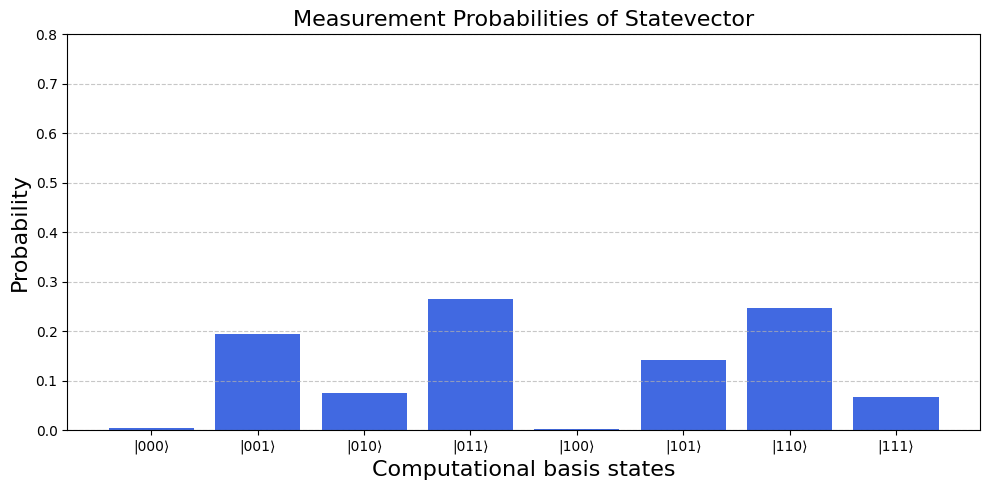

In [38]:
plot_statevector_probabilities(Statevector(evolu_w(x0)) )

In [69]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)   
bell.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘